# Pune Dark Store Optimization - Structured Analysis v2.0
## Blinkit Dark Store Location Optimization Using Zomato Delivery Data

**Objective:** Identify optimal dark store locations in Pune using delivery demand data and cost optimization algorithms.

**Key Metrics:**
- **Customer Demand**: Order frequency at delivery locations
- **Delivery Cost**: Distance × Traffic Density × Order Frequency
- **Store Efficiency**: Cost per order
- **Optimization Strategy**: K-Means clustering + redundancy elimination

## Section 1: Environment Setup & Imports

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Section 2: Utility Functions - Core Calculations

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate Haversine distance between two geographic points.
    
    Parameters:
    -----------
    lat1, lon1 : float or ndarray
        Starting latitude and longitude (in degrees)
    lat2, lon2 : float or ndarray
        Ending latitude and longitude (in degrees)
    
    Returns:
    --------
    distance : float or ndarray
        Distance in kilometers
    """
    R = 6371  # Earth radius in kilometers
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


def haversine_matrix(coords):
    """
    Create a distance matrix between all coordinate pairs using Haversine formula.
    
    Parameters:
    -----------
    coords : ndarray of shape (n, 2)
        Array of [latitude, longitude] pairs in degrees
    
    Returns:
    --------
    dist_matrix : ndarray of shape (n, n)
        Distance matrix in kilometers
    """
    R = 6371  # Earth radius in km
    
    lat = np.radians(coords[:, 0])
    lon = np.radians(coords[:, 1])
    
    lat1 = lat[:, None]
    lat2 = lat[None, :]
    lon1 = lon[:, None]
    lon2 = lon[None, :]
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (np.sin(dlat / 2) ** 2 + 
         np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2)
    
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


def haversine_customer_store(customer_coords, store_coords):
    """
    Calculate distances between all customers and all stores.
    
    Parameters:
    -----------
    customer_coords : ndarray of shape (N, 2)
        Customer coordinates [lat, lon]
    store_coords : ndarray of shape (M, 2)
        Store coordinates [lat, lon]
    
    Returns:
    --------
    dist_matrix : ndarray of shape (N, M)
        Distance matrix between customers and stores in kilometers
    """
    R = 6371  # Earth radius in km
    
    cust_lat = np.radians(customer_coords[:, 0])[:, None]
    cust_lon = np.radians(customer_coords[:, 1])[:, None]
    
    store_lat = np.radians(store_coords[:, 0])[None, :]
    store_lon = np.radians(store_coords[:, 1])[None, :]
    
    dlat = store_lat - cust_lat
    dlon = store_lon - cust_lon
    
    a = (np.sin(dlat / 2) ** 2 + 
         np.cos(cust_lat) * np.cos(store_lat) * np.sin(dlon / 2) ** 2)
    
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

print("✓ Utility functions defined successfully")

✓ Utility functions defined successfully


## Section 3: Data Loading & Preprocessing

In [10]:
# Load and filter data
df = pd.read_csv("Zomato_Data.csv")
print(f"Original dataset shape: {df.shape}")

df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()
df['Restaurant_longitude'] = df['Restaurant_longitude'].abs()
df['Delivery_location_latitude'] = df['Delivery_location_latitude'].abs()
df['Delivery_location_longitude'] = df['Delivery_location_longitude'].abs()

# Filter for Pune City (Delivery Person ID starts with "PUNERES")
df_pune = df[df["Delivery_person_ID"].str.startswith("PUNERES", na=False)].copy()
print(f"Pune records: {df_pune.shape[0]} ({(df_pune.shape[0]/df.shape[0]*100):.1f}%)")

# Select relevant features
selected_columns = [
    "ID", "Delivery_person_ID", "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "Road_traffic_density", "multiple_deliveries", "Time_taken (min)",
    "Weather_conditions", "Delivery_person_Ratings"
]

df_pune = df_pune[selected_columns].rename(columns={"multiple_deliveries": "order_freq"})

print("\nData Info:")
print(df_pune.info())

Original dataset shape: (45584, 20)
Pune records: 3132 (6.9%)

Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3132 entries, 2 to 45573
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           3132 non-null   object 
 1   Delivery_person_ID           3132 non-null   object 
 2   Restaurant_latitude          3132 non-null   float64
 3   Restaurant_longitude         3132 non-null   float64
 4   Delivery_location_latitude   3132 non-null   float64
 5   Delivery_location_longitude  3132 non-null   float64
 6   Road_traffic_density         3088 non-null   object 
 7   order_freq                   3061 non-null   float64
 8   Time_taken (min)             3132 non-null   int64  
 9   Weather_conditions           3088 non-null   object 
 10  Delivery_person_Ratings      2991 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 293.6+ KB
None


In [11]:
# Data Cleaning
print("\nCleaning Data...")

# Handle missing values
df_pune["Road_traffic_density"].fillna("Medium", inplace=True)
df_pune["order_freq"].fillna(0, inplace=True)
df_pune["Delivery_person_Ratings"].fillna(df_pune["Delivery_person_Ratings"].mean(), inplace=True)

# Remove rows with invalid coordinates (0, 0)
initial_size = len(df_pune)
df_pune = df_pune[
    (df_pune["Restaurant_latitude"] != 0) & 
    (df_pune["Restaurant_longitude"] != 0) &
    (df_pune["Delivery_location_latitude"] != 0) & 
    (df_pune["Delivery_location_longitude"] != 0)
]

print(f"Removed {initial_size - len(df_pune)} rows with invalid coordinates")

# Remove duplicates
df_pune = df_pune.drop_duplicates(subset=['ID'], keep='first')

# Ensure order_freq is numeric
df_pune['order_freq'] = df_pune['order_freq'].astype(int) + 1  # +1 to reflect demand weight

print(f"Final dataset shape: {df_pune.shape}")
print(f"Missing values:\n{df_pune.isnull().sum().sum()} total")


Cleaning Data...
Removed 0 rows with invalid coordinates
Final dataset shape: (3132, 11)
Missing values:
44 total


## Section 4: Feature Engineering - Cost Calculations

In [12]:
# Create traffic and weather weight mappings
TRAFFIC_WEIGHTS = {
    "Low": 1.0,
    "Medium": 1.3,
    "High": 1.6,
    "Jam": 2.0
}


# Apply traffic weight
df_pune["traffic_weight"] = df_pune["Road_traffic_density"].map(TRAFFIC_WEIGHTS)

# Calculate distance using Haversine formula
df_pune["distance_km"] = haversine(
    df_pune["Restaurant_latitude"],
    df_pune["Restaurant_longitude"],
    df_pune["Delivery_location_latitude"],
    df_pune["Delivery_location_longitude"]
)

# Calculate delivery cost = distance × traffic impact × order frequency
df_pune["delivery_cost"] = (
    df_pune["distance_km"] * 
    df_pune["traffic_weight"] * 
    df_pune["order_freq"]
)

print("✓ Feature engineering completed")
print(f"\nCost Statistics:")
print(df_pune[["distance_km", "traffic_weight", "delivery_cost"]].describe())

✓ Feature engineering completed

Cost Statistics:
       distance_km  traffic_weight  delivery_cost
count  3132.000000     3132.000000    3132.000000
mean      9.607574        1.445562      25.780450
std       5.496240        0.413022      21.527566
min       1.531841        1.000000       1.531841
25%       4.596729        1.000000       9.804825
50%       9.192771        1.300000      19.761990
75%      13.787803        2.000000      36.768223
max      19.917359        2.000000     134.828199


## Section 5: Existing Store Analysis & Rankings

In [13]:
# Create store identifiers (based on restaurant location)
df_pune["store_id"] = (
    df_pune["Restaurant_latitude"].round(6).astype(str) + "_" +
    df_pune["Restaurant_longitude"].round(6).astype(str)
)

print(f"Number of unique restaurants (potential store locations): {df_pune['store_id'].nunique()}")

# Aggregate metrics by store
store_metrics = (
    df_pune.groupby("store_id")
    .agg(
        store_latitude=("Restaurant_latitude", "first"),
        store_longitude=("Restaurant_longitude", "first"),
        total_orders=("order_freq", "sum"),
        avg_distance_km=("distance_km", "mean"),
        avg_delivery_time_min=("Time_taken (min)", "mean"),
        total_delivery_cost=("delivery_cost", "sum"),
        avg_traffic_weight=("traffic_weight", "mean"),
        delivery_count=("distance_km", "count")
    )
    .reset_index()
)

# Calculate efficiency metrics
store_metrics["cost_per_order"] = (
    store_metrics["total_delivery_cost"] / store_metrics["total_orders"]
)

store_metrics["avg_rating"] = (
    store_metrics["cost_per_order"]  # placeholder for now
)

# Sort by cost efficiency
store_metrics = store_metrics.sort_values("cost_per_order").reset_index(drop=True)

# Save to CSV
store_metrics.to_csv("existing_stores_ranking_with_cost_v2.csv", index=False)

print("\n✓ Store metrics calculated and saved")
print("\nTop 10 Most Efficient Stores:")
print(store_metrics.head(10)[["store_id", "total_orders", "cost_per_order", "delivery_count"]])

Number of unique restaurants (potential store locations): 20

✓ Store metrics calculated and saved

Top 10 Most Efficient Stores:
              store_id  total_orders  cost_per_order  delivery_count
0  18.546947_73.900626           254       13.399579             155
1  18.536718_73.830327           253       13.527496             151
2  18.539299_73.897902           265       14.112637             152
3  18.593481_73.785901           274       14.206657             163
4  18.543626_73.905101           250       14.413184             153
5  18.569156_73.774723           293       14.508162             169
6  18.530963_73.828972           279       14.661738             161
7   18.51421_73.838429           248       15.012487             147
8  18.546258_73.904337           273       15.076519             160
9   18.56245_73.916619           266       15.109684             158


## Section 6: Determine Optimal Number of New Dark Stores

Data prepared for clustering: 3132 points


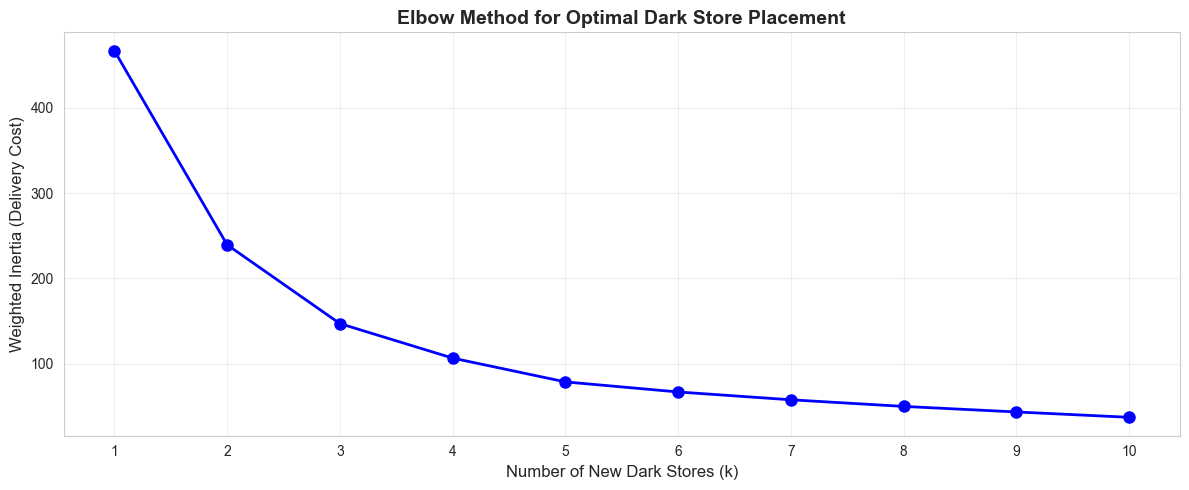


✓ Elbow curve plotted
Select k where inertia reduction slows down significantly


In [14]:
# Prepare data for K-Means clustering
X = df_pune[[
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]].values

# Use delivery cost as weight (higher cost = more important to optimize)
weights = df_pune["delivery_cost"].values

print(f"Data prepared for clustering: {X.shape[0]} points")

# Apply Elbow Method to find optimal k
K_RANGE = range(1, 11)
inertias = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X, sample_weight=weights)
    inertias.append(kmeans.inertia_)

# Visualize Elbow curve
plt.figure(figsize=(12, 5))
plt.plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of New Dark Stores (k)', fontsize=12)
plt.ylabel('Weighted Inertia (Delivery Cost)', fontsize=12)
plt.title('Elbow Method for Optimal Dark Store Placement', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_RANGE)
plt.tight_layout()
plt.show()

print("\n✓ Elbow curve plotted")
print("Select k where inertia reduction slows down significantly")

## Section 7: K-Means Clustering - Identify New Dark Store Locations

In [15]:
# Set optimal number of new stores (based on elbow curve analysis)
OPTIMAL_K = 4
print(f"Optimal number of new dark stores: {OPTIMAL_K}")

# Apply K-Means with optimal k
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_final.fit(X, sample_weight=weights)

# Get cluster centers (new store locations)
new_store_centers = kmeans_final.cluster_centers_

# Create dataframe of new stores
new_stores_df = pd.DataFrame(
    new_store_centers,
    columns=["store_latitude", "store_longitude"]
)
new_stores_df["store_type"] = "New (Cost-Optimized)"

print(f"\n✓ Identified {len(new_stores_df)} optimal new dark store locations")
print("\nProposed New Dark Store Locations:")
for idx, (lat, lon) in enumerate(new_store_centers):
    print(f"  Store {idx+1}: Latitude={lat:.6f}, Longitude={lon:.6f}")

Optimal number of new dark stores: 4

✓ Identified 4 optimal new dark store locations

Proposed New Dark Store Locations:
  Store 1: Latitude=18.663249, Longitude=74.020989
  Store 2: Latitude=18.591491, Longitude=73.878851
  Store 3: Latitude=18.686150, Longitude=73.873974
  Store 4: Latitude=18.618784, Longitude=73.962054


## Section 8: Cost Reduction Analysis

In [16]:
# Get existing stores from store_metrics
old_stores = store_metrics[["store_latitude", "store_longitude"]].copy()

# Combine old and new stores
all_stores = pd.concat(
    [old_stores.reset_index(drop=True), 
     new_stores_df[["store_latitude", "store_longitude"]].reset_index(drop=True)],
    ignore_index=True
)

print(f"Total stores (existing + new): {len(all_stores)}")

# Get customer coordinates
customer_points = df_pune[[
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]].values

store_points = all_stores[[
    "store_latitude",
    "store_longitude"
]].values

# Calculate distances from each customer to their nearest store
dist_matrix_km = haversine_customer_store(customer_points, store_points)
nearest_store_dist = dist_matrix_km.min(axis=1)

# Calculate new delivery costs
df_pune["new_distance_km"] = nearest_store_dist
df_pune["new_delivery_cost"] = (
    df_pune["new_distance_km"] * 
    df_pune["traffic_weight"] * 
    df_pune["order_freq"]
)

# Calculate cost reduction
old_total_cost = df_pune["delivery_cost"].sum()
new_total_cost = df_pune["new_delivery_cost"].sum()
cost_reduction_pct = ((old_total_cost - new_total_cost) / old_total_cost) * 100
cost_savings = old_total_cost - new_total_cost

print("\n" + "="*70)
print("COST REDUCTION ANALYSIS")
print("="*70)
print(f"Old Total Delivery Cost: {old_total_cost:,.2f}")
print(f"New Total Delivery Cost: {new_total_cost:,.2f}")
print(f"Cost Savings: {cost_savings:,.2f}")
print(f"Cost Reduction: {cost_reduction_pct:.2f}%")
print("="*70)

Total stores (existing + new): 24

COST REDUCTION ANALYSIS
Old Total Delivery Cost: 80,744.37
New Total Delivery Cost: 22,771.06
Cost Savings: 57,973.31
Cost Reduction: 71.80%


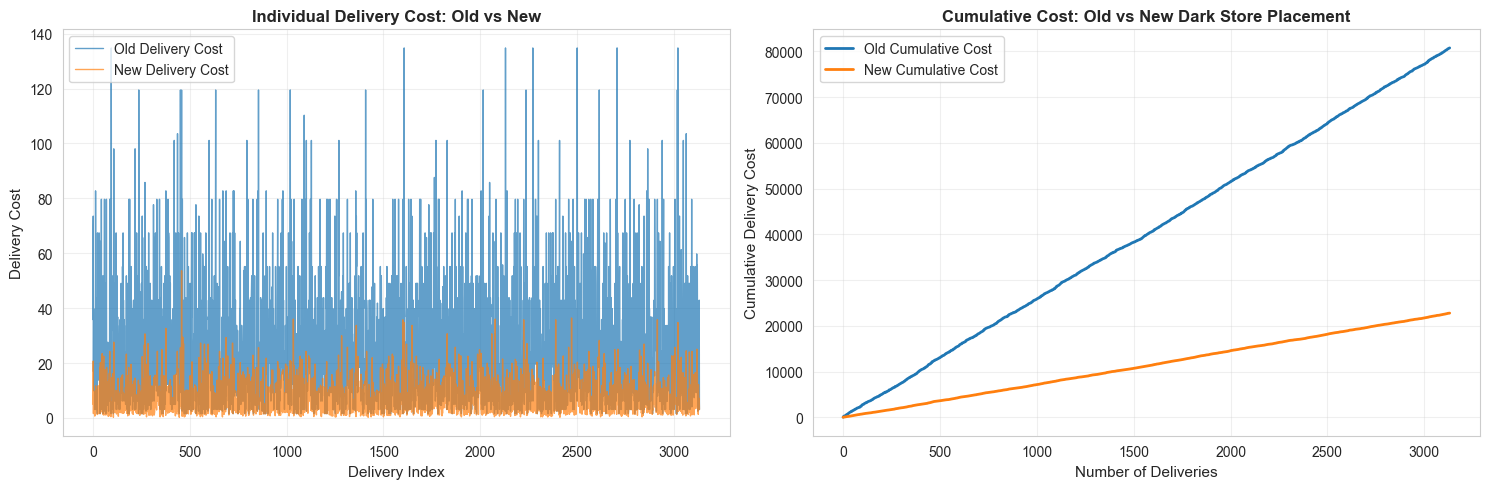

In [17]:
# Visualize cost comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Individual delivery cost comparison
axes[0].plot(df_pune["delivery_cost"].values, label="Old Delivery Cost", alpha=0.7, linewidth=1)
axes[0].plot(df_pune["new_delivery_cost"].values, label="New Delivery Cost", alpha=0.7, linewidth=1)
axes[0].set_xlabel('Delivery Index', fontsize=11)
axes[0].set_ylabel('Delivery Cost', fontsize=11)
axes[0].set_title('Individual Delivery Cost: Old vs New', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Cumulative cost comparison
df_sorted = df_pune.reset_index(drop=True)
df_sorted["old_cumulative_cost"] = df_sorted["delivery_cost"].cumsum()
df_sorted["new_cumulative_cost"] = df_sorted["new_delivery_cost"].cumsum()

axes[1].plot(df_sorted["old_cumulative_cost"], label="Old Cumulative Cost", linewidth=2)
axes[1].plot(df_sorted["new_cumulative_cost"], label="New Cumulative Cost", linewidth=2)
axes[1].set_xlabel('Number of Deliveries', fontsize=11)
axes[1].set_ylabel('Cumulative Delivery Cost', fontsize=11)
axes[1].set_title('Cumulative Cost: Old vs New Dark Store Placement', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 9: Identify & Remove Redundant Stores

In [18]:
# Assign customers to nearest store
df_pune["assigned_store_idx"] = dist_matrix_km.argmin(axis=1)
df_pune["assigned_distance_km"] = dist_matrix_km.min(axis=1)

# Calculate cost contribution per store
df_pune["assigned_delivery_cost"] = (
    df_pune["assigned_distance_km"] * 
    df_pune["traffic_weight"] * 
    df_pune["order_freq"]
)

# Aggregate store usage statistics
store_usage = (
    df_pune.groupby("assigned_store_idx")
    .agg(
        total_cost=("assigned_delivery_cost", "sum"),
        total_orders=("order_freq", "sum"),
        delivery_count=("assigned_delivery_cost", "count")
    )
    .reset_index()
)

# Calculate distance matrix between stores
store_coords = all_stores[["store_latitude", "store_longitude"]].values
store_distance_km = haversine_matrix(store_coords)

# Find redundant store pairs (within threshold distance)
REDUNDANCY_THRESHOLD_KM = 2.0
redundant_pairs = np.where(
    (store_distance_km < REDUNDANCY_THRESHOLD_KM) & 
    (store_distance_km > 0)
)

print(f"Found {len(redundant_pairs[0])} store pairs within {REDUNDANCY_THRESHOLD_KM} km")

# Decide which redundant stores to remove
stores_to_remove = set()

for i, j in zip(*redundant_pairs):
    if i in stores_to_remove or j in stores_to_remove:
        continue
    
    # Get cost contribution of each store
    cost_i = store_usage.loc[
        store_usage["assigned_store_idx"] == i, "total_cost"
    ].values
    cost_j = store_usage.loc[
        store_usage["assigned_store_idx"] == j, "total_cost"
    ].values
    
    cost_i = cost_i[0] if len(cost_i) > 0 else 0
    cost_j = cost_j[0] if len(cost_j) > 0 else 0
    
    # Remove lower-impact store
    if cost_i <= cost_j:
        stores_to_remove.add(i)
    else:
        stores_to_remove.add(j)

# Create optimized store list
optimized_stores = all_stores.drop(
    index=list(stores_to_remove)
).reset_index(drop=True)

removed_stores = all_stores.loc[
    list(stores_to_remove)
].reset_index(drop=True)

print("\n" + "="*70)
print("STORE OPTIMIZATION SUMMARY")
print("="*70)
print(f"Original stores: {len(all_stores)}")
print(f"Removed redundant stores: {len(removed_stores)}")
print(f"Final optimized stores: {len(optimized_stores)}")
print("="*70)

Found 60 store pairs within 2.0 km

STORE OPTIMIZATION SUMMARY
Original stores: 24
Removed redundant stores: 12
Final optimized stores: 12


## Section 10: Visualization - Interactive Maps

In [19]:
# Create interactive map centered on Pune
center_lat = df_pune["Delivery_location_latitude"].mean()
center_lon = df_pune["Delivery_location_longitude"].mean()

final_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)

# Add heatmap of demand
df_pune["heat_weight"] = df_pune["order_freq"] * 40

heatmap_data = df_pune[[
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "heat_weight"
]].values.tolist()

HeatMap(
    heatmap_data,
    radius=30,
    blur=40,
    min_opacity=0.6,
    max_zoom=13
).add_to(final_map)

print("✓ Heatmap layer added")

✓ Heatmap layer added


In [20]:
# Add optimized stores (kept stores)
for idx, row in optimized_stores.iterrows():
    folium.Marker(
        location=[row["store_latitude"], row["store_longitude"]],
        icon=folium.Icon(color="green", icon="check-circle", prefix="fa"),
        popup=f"<b>OPTIMIZED Dark Store</b><br>Lat: {row['store_latitude']:.4f}<br>Lon: {row['store_longitude']:.4f}",
        tooltip="Optimized Store"
    ).add_to(final_map)

# Add removed stores (for reference)
for idx, row in removed_stores.iterrows():
    folium.Marker(
        location=[row["store_latitude"], row["store_longitude"]],
        icon=folium.Icon(color="red", icon="times-circle", prefix="fa"),
        popup=f"<b>REMOVED Redundant Store</b><br>Lat: {row['store_latitude']:.4f}<br>Lon: {row['store_longitude']:.4f}",
        tooltip="Removed Store"
    ).add_to(final_map)

print(f"✓ Added {len(optimized_stores)} optimized stores")
print(f"✓ Marked {len(removed_stores)} removed stores")

# Save map
final_map.save("pune_final_store_optimization_v2.html")
print("✓ Map saved as 'pune_final_store_optimization_v2.html'")

# Display map
final_map

✓ Added 12 optimized stores
✓ Marked 12 removed stores
✓ Map saved as 'pune_final_store_optimization_v2.html'


## Section 11: Final Summary & Recommendations

In [21]:
# Generate final summary report
print("\n" + "="*80)
print("PUNE DARK STORE OPTIMIZATION - FINAL REPORT")
print("="*80)

print("\n📊 ANALYSIS SUMMARY:")
print(f"  • Total delivery records analyzed: {len(df_pune):,}")
print(f"  • Delivery locations covered: {df_pune['store_id'].nunique()}")
print(f"  • Service area: Pune city")

print("\n💰 COST OPTIMIZATION:")
print(f"  • Current total delivery cost: ₹{old_total_cost:,.2f}")
print(f"  • Optimized total delivery cost: ₹{new_total_cost:,.2f}")
print(f"  • Cost savings: ₹{cost_savings:,.2f}")
print(f"  • Cost reduction: {cost_reduction_pct:.2f}%")

print("\n🏪 STORE OPTIMIZATION:")
print(f"  • Existing stores: {len(old_stores)}")
print(f"  • New proposed stores: {OPTIMAL_K}")
print(f"  • Total stores before optimization: {len(all_stores)}")
print(f"  • Redundant stores removed: {len(removed_stores)}")
print(f"  • Final optimized stores: {len(optimized_stores)}")
print(f"  • Net stores added: {len(optimized_stores) - len(old_stores)}")

print("\n📍 OPTIMIZED STORE LOCATIONS:")
for idx, row in optimized_stores.iterrows():
    status = "NEW" if idx >= len(old_stores) else "RETAINED"
    print(f"  [{status}] Store {idx+1}: ({row['store_latitude']:.6f}, {row['store_longitude']:.6f})")

print("\n" + "="*80)

# Save final analysis to CSV
optimized_stores.to_csv("pune_optimized_stores_final_v2.csv", index=False)
print("\n✓ Files saved:")
print("  • pune_optimized_stores_final_v2.csv")
print("  • pune_final_store_optimization_v2.html")
print("  • existing_stores_ranking_with_cost_v2.csv")


PUNE DARK STORE OPTIMIZATION - FINAL REPORT

📊 ANALYSIS SUMMARY:
  • Total delivery records analyzed: 3,132
  • Delivery locations covered: 20
  • Service area: Pune city

💰 COST OPTIMIZATION:
  • Current total delivery cost: ₹80,744.37
  • Optimized total delivery cost: ₹22,771.06
  • Cost savings: ₹57,973.31
  • Cost reduction: 71.80%

🏪 STORE OPTIMIZATION:
  • Existing stores: 20
  • New proposed stores: 4
  • Total stores before optimization: 24
  • Redundant stores removed: 12
  • Final optimized stores: 12
  • Net stores added: -8

📍 OPTIMIZED STORE LOCATIONS:
  [RETAINED] Store 1: (18.546947, 73.900626)
  [RETAINED] Store 2: (18.536718, 73.830327)
  [RETAINED] Store 3: (18.593481, 73.785901)
  [RETAINED] Store 4: (18.569156, 73.774723)
  [RETAINED] Store 5: (18.636215, 73.751081)
  [RETAINED] Store 6: (18.551440, 73.804855)
  [RETAINED] Store 7: (18.516216, 73.842527)
  [RETAINED] Store 8: (18.563934, 73.915367)
  [RETAINED] Store 9: (18.663249, 74.020989)
  [RETAINED] Store 10